In [1]:
import pandas as pd

df = pd.read_csv("Alphabets_data.csv")

In [2]:
df.columns = df.columns.str.strip()

In [3]:
df.shape

(20000, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


In [5]:
df['letter'].unique()

df['letter'].nunique()

26

### Distribution (EDA)

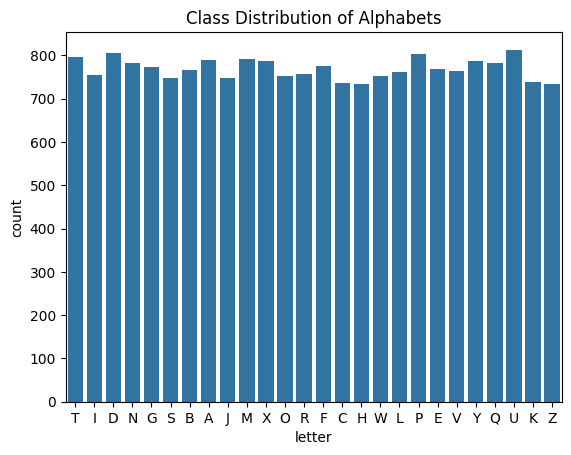

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='letter', data=df)
plt.title("Class Distribution of Alphabets")
plt.show()

###### This plot shows the distribution of different alphabet classes. It helps to identify whether the dataset is balanced or imbalanced.

### Missing Values Check

In [7]:
df.isnull().sum()

letter    0
xbox      0
ybox      0
width     0
height    0
onpix     0
xbar      0
ybar      0
x2bar     0
y2bar     0
xybar     0
x2ybar    0
xy2bar    0
xedge     0
xedgey    0
yedge     0
yedgex    0
dtype: int64

###### There are no missing values in the dataset, so no data cleaning is required.

### Label Encoding (Target Variable)

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['letter'] = le.fit_transform(df['letter'])

###### Categorical alphabet labels (A–Z) are converted into numerical values so that the neural network can process them.

### Feature Scaling (Normalization)

In [9]:
from sklearn.preprocessing import StandardScaler

X = df.drop('letter', axis=1)
y = df['letter']

scaler = StandardScaler()
X = scaler.fit_transform(X)

###### Feature scaling is applied to bring all input features to the same scale, which helps the neural network learn efficiently and converge faster.

### Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###### The dataset is split into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

### ANN Model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

# Input Layer 
model.add(Input(shape=(X_train.shape[1],)))

# Hidden Layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(26, activation='softmax'))

### Compile Model

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Model Evaluation

In [14]:
from sklearn.metrics import classification_report
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Convert probabilities → class labels
y_pred = np.argmax(y_pred, axis=1)

# Report
print(classification_report(y_test, y_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       149
           1       0.00      0.00      0.00       153
           2       0.00      0.00      0.00       137
           3       0.00      0.00      0.00       156
           4       0.27      0.06      0.10       141
           5       0.00      0.00      0.00       140
           6       0.00      0.00      0.00       160
           7       0.01      0.01      0.01       144
           8       0.00      0.00      0.00       146
           9       0.01      0.15      0.03       149
          10       0.39      0.09      0.15       130
          11       0.00      0.00      0.00       155
          12       0.00      0.00      0.00       168
          13       0.00      0.00      0.00       151
          14       0.01      0.01      0.01       145
          15       0.00      0.00      0.00       173
          16       0.08      0.29      0

C:\Users\Akhlaque Alam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Akhlaque Alam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Akhlaque Alam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

## Hyperparameter Tuning

#### Improved Model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model_tuned = Sequential()

model_tuned.add(Input(shape=(X_train.shape[1],)))

model_tuned.add(Dense(128, activation='relu'))
model_tuned.add(Dense(64, activation='relu'))
model_tuned.add(Dense(32, activation='relu'))

model_tuned.add(Dense(26, activation='softmax'))

###### The model complexity is increased by adding more layers and neurons to improve learning capability.

### Compile Tuned Model

In [16]:
model_tuned.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train Tuned Model

In [17]:
history_tuned = model_tuned.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5972 - loss: 1.4407 - val_accuracy: 0.7835 - val_loss: 0.7547
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8117 - loss: 0.6422 - val_accuracy: 0.8370 - val_loss: 0.5481
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8572 - loss: 0.4805 - val_accuracy: 0.8723 - val_loss: 0.4339
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8842 - loss: 0.3831 - val_accuracy: 0.8845 - val_loss: 0.3707
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9015 - loss: 0.3238 - val_accuracy: 0.8930 - val_loss: 0.3423
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9165 - loss: 0.2750 - val_accuracy: 0.9080 - val_loss: 0.3043
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9256 - loss: 0.2413 - val_accuracy: 0.9160 - val_loss: 0.2675
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9300 - loss: 0.2197 - val_accuracy: 0.

###### The tuned model is trained for more epochs to improve learning and overall performance.

### Evaluation & Comparison

In [18]:
# Predictions
y_pred_tuned = model_tuned.predict(X_test)
y_pred_tuned = y_pred_tuned.argmax(axis=1)

# Report
print(classification_report(y_test, y_pred_tuned, zero_division=0))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       149
           1       0.92      0.98      0.95       153
           2       0.98      0.91      0.94       137
           3       0.98      0.92      0.95       156
           4       0.91      0.97      0.94       141
           5       0.96      0.97      0.97       140
           6       0.95      0.93      0.94       160
           7       0.93      0.91      0.92       144
           8       0.95      0.96      0.96       146
           9       0.95      0.96      0.95       149
          10       0.91      0.93      0.92       130
          11       0.99      0.95      0.97       155
          12       0.98      0.98      0.98       168
          13       0.99      0.96      0.98       151
          14       0.96      0.97      0.96       145
          15       0.99      0.98      0.98       173
          16       0.98      0.95      0